# Data provenance, anti-leakage design, and next-notebook plan

## What data this notebook uses

This notebook builds respiration-based decoding datasets from multiple `.h5` sources and merges them into one processing stream.

### 1) AIM1 valence sessions
- `RI1_*` and `RI2_*` recordings (valence conditions)
- `BLRI_*` baseline recordings
- Loaded via the `resp_paths` dictionary

### 2) AIM1 cagemate sessions
- `CM_*` interaction recordings
- `BL_*` cagemate baseline recordings
- Loaded via `resp_paths_cm` and `resp_paths_bl`

### 3) Additional BLA cohort cagemate recordings
- Pulled from:
  - `D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs`
  - `D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs`
- Filenames are renamed with `rename_map` so subject IDs are unique when combining cohorts

### 4) Labeling and metadata
- `rank_map` maps subject IDs (example: `1_1`, `1_2`) to `Subordinate` / `Dominant`
- Trial metadata is parsed from trial names:
  - `Condition` from prefix (`RI1`, `RI2`, `CM`, `BL`, `BLRI`)
  - `Subject` from ID tokens in trial key
  - `Rank` from `rank_map` (or file suffixes for some renamed BLA files)

### 5) Final sample table built in this notebook
- Main table: `resp_sample_df`
- Columns used in modeling sections:
  - `Trial`
  - `Subject`
  - `Condition`
  - `Rank`
  - `RespRate`
- Feature currently used for classifiers: **only** `RespRate`

---

## How this notebook organizes data to reduce leakage

### Current good practice already present
For several analyses, this notebook uses:
- `groups = df_val["Subject"]`
- `GroupKFold(...)`

That is the right idea because each mouse appears in many windows/trials. Grouping by `Subject` prevents the same mouse from being in both train and test folds in those runs.

### Why leakage is a real risk here
The pipeline creates many random windows (`n_samples=100`) per recording. Those windows from one mouse are highly correlated. If you split at window level (instead of subject/group level), the model can memorize mouse-specific patterns (including dominant/subordinate identity proxies) instead of learning generalizable respiration biology.

### Leakage risk still present in this notebook
There are also sections using `StratifiedKFold` on window rows (no grouping), which can mix windows from the same subject into train and test. Those results are likely optimistic for repeated-mouse data.

---

## Critical grouping principle for repeated dominant/subordinate mice

Because mice are repeated and rank is stable within each mouse, **evaluation must split by mouse identity** (or stricter).

Use this hierarchy:

1. **Best minimum**: split by `Subject` (GroupKFold / GroupShuffleSplit)
2. **Stricter for dyad confounds**: split by cage pair/dyad (e.g., `1_1-1_2`) so neither mouse from a pair appears in both train and test
3. **Strictest for cohort/site confounds**: nested/grouped splits that also isolate cohort (`AIM1` vs BLA) in outer evaluation

If the goal is rank decoding generalization to unseen mice, never report window-level stratified CV alone.

---

## Recommended design for the next notebook (more features + preprocessing)

## A) Data table structure to build first
Create one master dataframe where every row is one fixed window from one trial:

Required ID columns:
- `cohort` (AIM1 or BLA)
- `trial_id`
- `subject_id`
- `partner_id` (if present)
- `dyad_id` (canonical sorted pair key)
- `condition` (`RI1`, `RI2`, `CM`, `BL`, `BLRI`, etc.)
- `rank_label` (`Dominant`/`Subordinate`)
- `session_date` or recording block
- `window_id`

Feature columns:
- `resp_rate` and future extracted features (time-domain, frequency, variability, waveform-shape)

This ID-first table is the anti-leakage backbone.

## B) Preprocessing rules (fit only on train folds)
For each CV fold:
1. Split by groups first (subject/dyad)
2. Fit preprocessing on train only:
   - scaling
   - imputation
   - optional PCA / feature selection
3. Apply fitted transformers to test

Put all preprocessing inside an sklearn `Pipeline` so leakage through preprocessing is impossible.

## C) Windowing strategy improvements
- Keep windows non-overlapping within a trial (already partly done)
- Track `window_start`, `window_end`
- Use consistent window duration per experiment (or include as metadata)
- For robustness: evaluate multiple random seeds for window sampling and aggregate metrics

## D) Evaluation protocol to report
Use two complementary evaluations:

1. **Primary (required):** Grouped CV by `subject_id` (or `dyad_id` for stricter test)
2. **Secondary:** Cohort transfer
   - Train on AIM1, test on BLA
   - Train on BLA, test on AIM1

Report:
- ROC AUC, PR AUC, balanced accuracy, calibration (if probabilistic outputs)
- mean ± SEM or 95% CI over folds
- per-group performance (dominant vs subordinate, each cohort)

## E) Aggregation checks to avoid pseudo-replication
Also create subject-level summaries:
- average features per subject per condition/session
- train/test on these summaries as a sensitivity analysis

If window-level and subject-level results disagree strongly, treat window-level gains cautiously.

## F) Confound checks for rank task
Because rank and mouse identity are tightly linked:
- verify no subject overlap between train/test in every split
- test whether adding explicit identity proxies changes performance drastically
- check dyad leakage explicitly (`dyad_id` overlap)
- run label permutation within training folds as a sanity check

---

## Practical split templates for this project

### Rank decoding (CM only)
- `X = feature_matrix`
- `y = rank_label`
- `groups = subject_id` (minimum) or `dyad_id` (stricter)
- CV: `GroupKFold` or repeated `GroupShuffleSplit`

### Valence decoding (RI1 vs RI2)
- `X = feature_matrix`
- `y = condition_binary`
- `groups = subject_id`
- Optional: stratify at group level by dominant/subordinate balance if feasible

### Combined-cohort modeling
- include `cohort` column
- evaluate both pooled-group CV and leave-one-cohort-out transfer

---

## What else can be done next (high-value additions)

1. Add richer respiration features beyond rate:
   - inter-breath interval variability
   - spectral band power and peak frequency
   - inhale/exhale duration ratio
   - amplitude and shape descriptors

2. Add quality-control flags per window:
   - signal dropout/artifact ratio
   - confidence score for breath detection
   - exclude low-quality windows before modeling

3. Use nested grouped CV for tuning:
   - outer grouped split for honest test
   - inner grouped split for hyperparameter tuning

4. Compare model families under same grouped protocol:
   - logistic regression baseline
   - regularized linear models
   - tree-based models (with careful overfitting control)

5. Perform ablations:
   - RespRate-only vs full feature set
   - AIM1-only vs BLA-only vs pooled
   - subject-grouped vs dyad-grouped split sensitivity

---

## Bottom line
For this repeated-mouse dominant/subordinate design, leakage control is mainly a **split-definition problem**. The next notebook should treat `subject_id`/`dyad_id` as first-class grouping keys, keep preprocessing strictly fold-local, and report grouped generalization as the primary result. This will make future feature-extraction improvements scientifically interpretable and trustworthy.

In [1]:
# ======================================================
# Core libraries for respiration + social behavior analysis
# ======================================================

# --- Core Python ---
import os
import h5py
import re
import glob
# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline



# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)




In [2]:
# ======================================================
# Define file paths and rank map
# ======================================================

# --- Define social rank map for all subjects ---
rank_map = {
    "1_1": "Subordinate",
    "1_2": "Dominant",
    "2_3": "Subordinate",
    "2_4": "Dominant",
    "3_5": "Subordinate",
    "3_6": "Dominant",
    "4_7": "Subordinate",
    "4_8": "Dominant"
}

# --------------------------------------------------
# Dominant–Subordinate subject pairs
# --------------------------------------------------
pair_groups = [
    ["1_1", "1_2"],
    ["2_3", "2_4"],
    ["3_5", "3_6"],
    ["4_7", "4_8"],
]

# ======================================================
# Respiration + BORIS paths (valence and cagemate sets)
# ======================================================

# --- Valence (RI1, RI2, BLRI) ---
resp_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5",
    "RI1_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5",
    # Baseline recordings (pre-valence)
    "BLRI_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5",
    "BLRI_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5",
    "BLRI_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5",
    "BLRI_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5",
    "BLRI_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5",
    "BLRI_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5",
    "BLRI_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5",
}


# --- Cagemate interaction (CM) and baselines (BL) ---

resp_paths_bl = {
    "BL_1_1_d1_2": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_1_d1_2_20250623_103713_merged.h5",
    "BL_1_2_sub1_1": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_2_sub_1_1_20250623_120135_merged.h5",
    "BL_2_3_d2_4": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_3_d2_4_20250623_145448_merged.h5",
    "BL_2_4_sub2_3": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_4_sub2_3_20250623_141419_merged.h5",
    "BL_3_5_d3_6": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_5_d3_6_20250623_154154_merged.h5",
    "BL_3_6_sub3_5": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_6_sub3_5_20250623_172635_merged.h5",
    "BL_4_7_d4_8": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_7_d4_8_20250623_185042_merged.h5",
    "BL_4_8_sub4_7": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_8_sub4_7_20250623_180810_merged.h5"
}

resp_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_1_d1_2_20250623_111352_merged.h5",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_2_sub1_1_20250623_133932_merged.h5",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_3_d2_4_20250623_151153_merged.h5",
    "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_4_sub2_3_20250623_143348_merged.h5",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_5_d3_6_20250623_170708_merged.h5",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_6_sub3_5_20250623_174348_merged.h5",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_7_d4_8_20250623_193718_merged.h5",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_8_sub4_7_20250623_182649_merged.h5",
}

# ======================================================
# Added new cagemate recording data
# ======================================================
dirs = [
    r"D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs",
    r"D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs",
]

all_files = []
for d in dirs:
    all_files.extend(glob.glob(os.path.join(d, "*.h5")))

# ======================================================
# Summary check
# ======================================================

def summarize_paths(resp_dict, boris_dict, label):
    resp_set = set(resp_dict.keys())
    boris_set = set(boris_dict.keys())
    missing = resp_set - boris_set
    print(f"\n {label} summary")
    print(f"Resp files: {len(resp_set)} | BORIS files: {len(boris_set)} | No BORIS: {len(missing)}")
    if missing:
        print("Missing trials:", ", ".join(sorted(missing)))

# ======================================================
# Organized summaries by experiment type
# ======================================================

# --- Split out subsets for clarity ---
resp_paths_valence = {k: v for k, v in resp_paths.items() if k.startswith(("RI1", "RI2"))}
resp_paths_blri = {k: v for k, v in resp_paths.items() if k.startswith("BLRI")}
resp_paths_cm_only = {k: v for k, v in resp_paths_cm.items() if k.startswith("CM")}
resp_paths_bl_only = {k: v for k, v in resp_paths_bl.items() if k.startswith("BL")}


# ======================================================
# Combine all for unified processing later
# ======================================================
all_resp_paths = {**resp_paths_valence, **resp_paths_blri, **resp_paths_cm_only, **resp_paths_bl_only}


print(f"\n Combined respiration files total: {len(all_resp_paths)}")






 Combined respiration files total: 39


In [3]:
bla_cm_files = [f for f in all_files if "cm_hc" in f]
aim1_cm_files = list(resp_paths_cm.values())

print("BLA CM:", len(bla_cm_files))
print("AIM1 CM:", len(aim1_cm_files))

BLA CM: 24
AIM1 CM: 8


this is to add the cohort number and the relitive rak for the recording to the new data so when i combine the new data subj have unique IDs

In [4]:
rename_map = {
    "1_1_i_cm_1_2_d_20260106_134350.h5": "1_1_2_i_cm_1_2_d_20260106_134350_SUB.h5",
    "1_1_i_cm_1_3_s_20260107_163611.h5": "1_1_2_i_cm_1_3_s_20260107_163611_DOM.h5",
    "1_2_d_cm_1_3_s_20260108_114416.h5": "1_2_2_d_cm_1_3_s_20260108_114416_DOM.h5",
    "1_3_s_cm_1_1_i_20260106_122823.h5": "1_3_2_s_cm_1_1_i_20260106_122823_DOM.h5",
    "1_3_s_cm_1_2_d_20260107_165340.h5": "1_3_2_s_cm_1_2_d_20260107_165340_SUB.h5",
    "2_1_d_cm_2.3_i_20260106_105109.h5": "2_1_2_d_cm_2.3_i_20260106_105109_SUB.h5",
    "2_1_d_cm_2_2_s_20260108_112426.h5": "2_1_2_d_cm_2_2_s_20260108_112426_DOM.h5",
    "2_2_s_cm_2_1_d_20260108_120453.h5": "2_2_2_s_cm_2_1_d_20260108_120453_SUB.h5",
    "2_2_s_cm_2_3_i_20260106_132549.h5": "2_2_2_s_cm_2_3_i_20260106_132549_DOM.h5",
    "3_1_i_cm_3_2_d_20260106_115157.h5": "3_1_2_i_cm_3_2_d_20260106_115157_SUB.h5",
    "3_1_i_cm_3_3_s_20260107_123230.h5": "3_1_2_i_cm_3_3_s_20260107_123230_DOM.h5",
    "3_2_d_cm_3_3_s_20260107_140924.h5": "3_2_2_d_cm_3_3_s_20260107_140924_DOM.h5",
    "3_3_s_cm_3_1_i_20260106_124546.h5": "3_3_2_s_cm_3_1_i_20260106_124546_DOM.h5",
    "3_3_s_cm_3_2_d_20260107_171330.h5": "3_3_2_s_cm_3_2_d_20260107_171330_SUB.h5",
    "4_1_s_cm_4_2_d_20260107_160439.h5": "4_1_2_s_cm_4_2_d_20260107_160439_SUB.h5",
    "4_2_d_cm_4_1_s_20260107_150836.h5": "4_2_2_d_cm_4_1_s_20260107_150836_DOM.h5",
    "4_3_d_cm_4_1_s_20260107_113120.h5": "4_3_2_d_cm_4_1_s_20260107_113120_DOM.h5",
    "5_1_i_cm_5_2_d_20260106_120946.h5": "5_1_2_i_cm_5_2_d_20260106_120946_SUB.h5",
    "5_1_i_cm_5_3_s_20260107_132309.h5": "5_1_2_i_cm_5_3_s_20260107_132309_DOM.h5",
    "6_2_d_cm_6_3_s_20260107_154939.h5": "6_2_2_d_cm_6_3_s_20260107_154939_DOM.h5",
    "7_1_d_cm_7_2_s_20260106_111330.h5": "7_1_2_d_cm_7_2_s_20260106_111330_DOM.h5",
    "7_2_s_cm_7_1_d_20260106_130431.h5": "7_2_2_s_cm_7_1_d_20260106_130431_SUB.h5",
    "8_1_s_cm_8_2_d_20260107_152812.h5": "8_1_2_s_cm_8_2_d_20260107_152812_SUB.h5",
    "8_2_s_cm_8_1_d_20260106_113241.h5": "8_2_2_s_cm_8_1_d_20260106_113241_SUB.h5",
}

preprocess both data aim1 and bla

In [5]:
def load_clean_resp_signal(h5_file, target_rate=100):

    try:
        with h5py.File(h5_file, 'r') as f:

            keys = list(f.keys())

            # -------------------------
            # BLA format (resp_clean)
            # -------------------------
            if "resp_clean" in keys:
                signal = f["resp_clean"]["signal"][:]
                time = f["resp_clean"]["time"][:]

                return signal, time, target_rate, {"source": "BLA"}

            # -------------------------
            # AIM1 format (resp)
            # -------------------------
            elif "resp" in keys:
                resp = f["resp"][:].flatten()

                metadata = {}
                if "resp_metadata" in f:
                    metadata.update(dict(f["resp_metadata"].attrs))
                if "metadata" in f:
                    metadata.update(dict(f["metadata"].attrs))

                # sampling rate
                if "sampling_frequency" in metadata:
                    fs = metadata["sampling_frequency"]
                else:
                    duration_sec = metadata.get("duration_sec", None)
                    fs = len(resp) / duration_sec if duration_sec else 20000.0

                # filter + downsample
                from scipy.signal import butter, filtfilt, resample_poly

                nyquist = fs / 2
                cutoff = target_rate / 2
                b, a = butter(4, cutoff / nyquist, btype='low')
                filtered = filtfilt(b, a, resp)

                down_factor = int(round(fs / target_rate))
                down = resample_poly(filtered, up=1, down=down_factor)

                time = np.arange(len(down)) / target_rate

                return down, time, target_rate, metadata

            else:
                print(f"Unknown format: {h5_file} | keys={keys}")
                return None, None, None, None

    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None, None

changing the name of the bla files so that subj are unique for AIM1 and BLA _2 == bla

In [6]:
import os

for f in all_files:
    fname = os.path.basename(f)
    
    if fname not in rename_map:
        print("Skipping (not mapped):", fname)
        continue
    
    new_name = rename_map[fname]
    new_path = os.path.join(os.path.dirname(f), new_name)
    
    print(fname, "→", new_name)  # preview
    
    # uncomment when ready
    os.rename(f, new_path)

Skipping (not mapped): 1_1_bl_cc_20260105_151056.h5
Skipping (not mapped): 1_2_bl_cc_20260105_202137.h5
Skipping (not mapped): 1_3_bl_cc_20260105_172919.h5
Skipping (not mapped): 2_1_bl_cc_20260105_142514.h5
Skipping (not mapped): 2_2_bl_cc_20260105_193029.h5
Skipping (not mapped): 2_3_bl_cc_20260105_174734.h5
Skipping (not mapped): 3_1_bl_cc_20260105_163038.h5
Skipping (not mapped): 3_2_bl_cc_20260105_121340.h5
Skipping (not mapped): 3_3_bl_cc_20260105_185619.h5
Skipping (not mapped): 4_1_bl_cc_20260105_183238.h5
Skipping (not mapped): 4_2_bl_cc_20260105_152759.h5
Skipping (not mapped): 4_3_bl_cc_20260105_204142.h5
Skipping (not mapped): 5_1_bl_cc_20260105_170807.h5
Skipping (not mapped): 5_2_bl_cc_20260105_194714.h5
Skipping (not mapped): 5_3_bl_cc_20260105_132320.h5
Skipping (not mapped): 6_3_bl_cc_20260105_154627.h5
Skipping (not mapped): 7_1_bl_cc_20260105_144447.h5
Skipping (not mapped): 7_2_bl_cc_20260105_191314.h5
Skipping (not mapped): 7_3_bl_cc_20260105_181446.h5
Skipping (no

In [7]:
print(all_files[0])

D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs\1_1_bl_cc_20260105_151056.h5


old but not deleting yet 

In [116]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal, time vector, and metadata.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()

            # Load metadata if available
            metadata = {}
            if 'resp_metadata' in f:
                metadata.update(dict(f['resp_metadata'].attrs))
            if 'ekg_metadata' in f:
                metadata.update(dict(f['ekg_metadata'].attrs))
            if 'metadata' in f:
                metadata.update(dict(f['metadata'].attrs))

            # Estimate sampling frequency
            if 'sampling_frequency' in metadata:
                fs = metadata['sampling_frequency']
            else:
                duration_sec = metadata.get('duration_sec', None)
                fs = len(resp) / duration_sec if duration_sec else 20000.0

            duration_sec = metadata.get('duration_sec', len(resp) / fs)

    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate, metadata


In [8]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    # mask the signal window
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # detect peaks with a tighter minimum distance 12 Hz max rate)
    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # 0.0833 s = 12 Hz
    peak_times = time_sniff[peaks]

    # need at least 2 peaks to compute IBI
    if len(peak_times) < 2:
        return np.nan

    # compute IBI
    ibi = np.diff(peak_times)  # seconds

    # instantaneous rate
    inst_rate = 1.0 / ibi      # Hz

    # return average instantaneous rate (one number, same format as old code)
    avg_rate = np.mean(inst_rate)

    return avg_rate

In [9]:
def get_instantaneous_resp_rate(signal, time, sampling_rate=100):
    """
    Computes inter-breath intervals (IBI) and instantaneous respiration rate (Hz).

    Parameters
    ----------
    signal : np.ndarray
        Cleaned respiration trace (filtered and downsampled).
    time : np.ndarray
        Time vector (seconds).
    sampling_rate : float, default=100
        Sampling rate of respiration signal (Hz).

    Returns
    -------
    ibi : np.ndarray
        Inter-breath intervals (seconds).
    inst_rate : np.ndarray
        Instantaneous respiration rate (Hz = 1 / IBI).
    inst_time : np.ndarray
        Time vector aligned to each instantaneous rate (midpoint between consecutive peaks).
    peaks : np.ndarray
        Indices of detected peaks.
    """
    min_distance = int(sampling_rate * 0.0833)  # 12 Hz upper cutoff
    peaks, _ = find_peaks(signal, distance=min_distance)

    if len(peaks) < 2:
        print("Warning: insufficient peaks for IBI calculation")
        return np.array([]), np.array([]), np.array([]), peaks

    peak_times = time[peaks]
    ibi = np.diff(peak_times)
    inst_rate = 1.0 / ibi
    inst_time = peak_times[:-1] + ibi / 2

    return ibi, inst_rate, inst_time, peaks


In [10]:
def plot_instantaneous_resp(signal, time, inst_time, inst_rate, peaks=None, title="Instantaneous Respiration Rate"):
    """
    Plots respiration signal with detected peaks and instantaneous rate over time.

    Parameters
    ----------
    signal : np.ndarray
        Cleaned respiration trace.
    time : np.ndarray
        Time vector (seconds).
    inst_time : np.ndarray
        Midpoints of inter-breath intervals (s).
    inst_rate : np.ndarray
        Instantaneous respiration rate (Hz = 1/IBI).
    peaks : np.ndarray or None
        Optional indices of detected inhalation peaks.
    title : str
        Figure title.
    """
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                           gridspec_kw={'height_ratios': [2, 1]})

    # --- Top: respiration signal ---
    ax[0].plot(time, signal, color="gray", lw=1.0)
    if peaks is not None and len(peaks) > 0:
        ax[0].plot(time[peaks], signal[peaks], "r.", markersize=4)
    ax[0].set_ylabel("Amplitude (a.u.)")
    ax[0].set_title(title)
    ax[0].grid(True, linestyle=":", alpha=0.5)

    # --- Bottom: instantaneous rate ---
    ax[1].plot(inst_time, inst_rate, color="teal", lw=1.5)
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Rate (Hz)")
    ax[1].grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()


In [11]:
# --- Pick one session to test ---
trial_key = "CM_2_4_sub2_3"
resp_path = resp_paths_cm[trial_key]

# --- Load respiration ---
resp_signal, time, fs, meta = load_clean_resp_signal(resp_path)

# --- Compute session-wide respiration rate ---
sniff_start = time[0]
sniff_end = time[-1]

avg_rate = get_sniff_respiratory_rate(
    signal=resp_signal,
    time=time,
    sniff_start=sniff_start,
    sniff_end=sniff_end,
    sampling_rate=fs
)

# --- Extract identifiers automatically ---
condition = trial_key.split("_")[0]              # e.g., "CM"
subject_id = "_".join(trial_key.split("_")[1:3]) # e.g., "2_4"

# --- Print summary ---
print(f"Session: {condition} | Subject: {subject_id}")
print(f"Average respiration rate: {avg_rate:.2f} Hz")
print(f"Sampling rate: {fs:.0f} Hz | Duration: {time[-1]:.1f} sec")


Session: CM | Subject: 2_4
Average respiration rate: 7.50 Hz
Sampling rate: 100 Hz | Duration: 622.0 sec


In [12]:
# --- Pick one BLA session ---
resp_path = all_files[0]   # or pick a specific file

import os
fname = os.path.basename(resp_path).replace(".h5", "")

In [13]:
# --- Load respiration ---
resp_signal, time, fs, meta = load_clean_resp_signal(resp_path)

# --- Compute session-wide respiration rate ---
sniff_start = time[0]
sniff_end = time[-1]

avg_rate = get_sniff_respiratory_rate(
    signal=resp_signal,
    time=time,
    sniff_start=sniff_start,
    sniff_end=sniff_end,
    sampling_rate=fs
)

In [14]:
parts = fname.split("_")

condition = "CM"  # because you filtered to CM files

# subject now includes _2
subject_id = f"{parts[0]}_{parts[1]}_{parts[2]}"

# rank from filename
if "_SUB" in fname:
    rank = "Subordinate"
elif "_DOM" in fname:
    rank = "Dominant"
else:
    rank = None

example of new data BLA files

In [15]:
print(f"Session: {condition} | Subject: {subject_id} | Rank: {rank}")
print(f"Average respiration rate: {avg_rate:.2f} Hz")
print(f"Sampling rate: {fs:.0f} Hz | Duration: {time[-1]:.1f} sec")

Session: CM | Subject: 1_1_bl | Rank: None
Average respiration rate: 8.43 Hz
Sampling rate: 100 Hz | Duration: 614.5 sec


checking files


In [16]:
for f in all_files[:46]:
    print(os.path.basename(f))

1_1_bl_cc_20260105_151056.h5
1_2_bl_cc_20260105_202137.h5
1_3_bl_cc_20260105_172919.h5
2_1_bl_cc_20260105_142514.h5
2_2_bl_cc_20260105_193029.h5
2_3_bl_cc_20260105_174734.h5
3_1_bl_cc_20260105_163038.h5
3_2_bl_cc_20260105_121340.h5
3_3_bl_cc_20260105_185619.h5
4_1_bl_cc_20260105_183238.h5
4_2_bl_cc_20260105_152759.h5
4_3_bl_cc_20260105_204142.h5
5_1_bl_cc_20260105_170807.h5
5_2_bl_cc_20260105_194714.h5
5_3_bl_cc_20260105_132320.h5
6_3_bl_cc_20260105_154627.h5
7_1_bl_cc_20260105_144447.h5
7_2_bl_cc_20260105_191314.h5
7_3_bl_cc_20260105_181446.h5
8_1_bl_cc_20260105_200351.h5
8_2_bl_cc_20260105_161205.h5
8_3_bl_cc_20260105_134953.h5
1_1_2_i_cm_1_2_d_20260106_134350_SUB.h5
1_1_2_i_cm_1_3_s_20260107_163611_DOM.h5
1_2_2_d_cm_1_3_s_20260108_114416_DOM.h5
1_3_2_s_cm_1_1_i_20260106_122823_DOM.h5
1_3_2_s_cm_1_2_d_20260107_165340_SUB.h5
2_1_2_d_cm_2.3_i_20260106_105109_SUB.h5
2_1_2_d_cm_2_2_s_20260108_112426_DOM.h5
2_2_2_s_cm_2_1_d_20260108_120453_SUB.h5
2_2_2_s_cm_2_3_i_20260106_132549_DOM.h5
3_

In [17]:
analysis_files = [f for f in all_files if "cm_hc" in f and ("_SUB" in f or "_DOM" in f)]

print(len(analysis_files))
print(analysis_files[:3])

24
['D:\\BLA_ChR_resp\\BLA_resp_ChR_cm_hc\\h5_outputs\\1_1_2_i_cm_1_2_d_20260106_134350_SUB.h5', 'D:\\BLA_ChR_resp\\BLA_resp_ChR_cm_hc\\h5_outputs\\1_1_2_i_cm_1_3_s_20260107_163611_DOM.h5', 'D:\\BLA_ChR_resp\\BLA_resp_ChR_cm_hc\\h5_outputs\\1_2_2_d_cm_1_3_s_20260108_114416_DOM.h5']


In [18]:
rows = []

for resp_path in analysis_files:
    
    fname = os.path.basename(resp_path).replace(".h5", "")
    
    # -----------------------------
    # Load respiration (same as before)
    # -----------------------------
    resp_signal, time, fs, meta = load_clean_resp_signal(resp_path)
    
    if resp_signal is None or time is None:
        print("Bad file:", fname)
        continue
    
    # -----------------------------
    # Compute rate (same as before)
    # -----------------------------
    sniff_start = time[0]
    sniff_end = time[-1]
    
    avg_rate = get_sniff_respiratory_rate(
        signal=resp_signal,
        time=time,
        sniff_start=sniff_start,
        sniff_end=sniff_end,
        sampling_rate=fs
    )
    
    if avg_rate is None:
        print("No rate:", fname)
        continue
    
    # -----------------------------
    # Extract identifiers (same logic)
    # -----------------------------
    parts = fname.split("_")
    
    subject_id = f"{parts[0]}_{parts[1]}_{parts[2]}"
    condition = "CM"
    
    if "_SUB" in fname:
        rank = "Subordinate"
    elif "_DOM" in fname:
        rank = "Dominant"
    else:
        continue
    
    # -----------------------------
    # Store ONE row per session
    # -----------------------------
    rows.append({
        "Trial": fname,
        "Subject": subject_id,
        "Condition": condition,
        "Rank": rank,
        "RespRate": avg_rate
    })

bla dataframe created 

In [19]:
df_bla = pd.DataFrame(rows)

print(df_bla.shape)
print(df_bla.head())

(24, 5)
                                  Trial Subject Condition         Rank  RespRate
0  1_1_2_i_cm_1_2_d_20260106_134350_SUB   1_1_2        CM  Subordinate  8.480488
1  1_1_2_i_cm_1_3_s_20260107_163611_DOM   1_1_2        CM     Dominant  8.429625
2  1_2_2_d_cm_1_3_s_20260108_114416_DOM   1_2_2        CM     Dominant  8.459066
3  1_3_2_s_cm_1_1_i_20260106_122823_DOM   1_3_2        CM     Dominant  8.426108
4  1_3_2_s_cm_1_2_d_20260107_165340_SUB   1_3_2        CM  Subordinate  8.160981


In [20]:
df_bla = pd.DataFrame(rows)

print(df_bla.shape)
print(df_bla.head())

(24, 5)
                                  Trial Subject Condition         Rank  RespRate
0  1_1_2_i_cm_1_2_d_20260106_134350_SUB   1_1_2        CM  Subordinate  8.480488
1  1_1_2_i_cm_1_3_s_20260107_163611_DOM   1_1_2        CM     Dominant  8.429625
2  1_2_2_d_cm_1_3_s_20260108_114416_DOM   1_2_2        CM     Dominant  8.459066
3  1_3_2_s_cm_1_1_i_20260106_122823_DOM   1_3_2        CM     Dominant  8.426108
4  1_3_2_s_cm_1_2_d_20260107_165340_SUB   1_3_2        CM  Subordinate  8.160981


In [21]:
def load_clean_resp_signal(h5_file, target_rate=100):

    try:
        with h5py.File(h5_file, 'r') as f:

            keys = list(f.keys())

            # =========================
            # BLA format (resp_clean)
            # =========================
            if "resp_clean" in keys:
                signal = f["resp_clean"]["signal"][:]
                time = f["resp_clean"]["time"][:]

                return signal, time, target_rate, {"source": "BLA"}

            # =========================
            # AIM1 format (resp)
            # =========================
            elif "resp" in keys:
                resp = f["resp"][:].flatten()

                metadata = {}
                if "resp_metadata" in f:
                    metadata.update(dict(f["resp_metadata"].attrs))
                if "metadata" in f:
                    metadata.update(dict(f["metadata"].attrs))

                # sampling rate
                if "sampling_frequency" in metadata:
                    fs = metadata["sampling_frequency"]
                else:
                    duration_sec = metadata.get("duration_sec", None)
                    fs = len(resp) / duration_sec if duration_sec else 20000.0

                from scipy.signal import butter, filtfilt, resample_poly

                nyquist = fs / 2
                cutoff = target_rate / 2
                b, a = butter(4, cutoff / nyquist, btype='low')
                filtered = filtfilt(b, a, resp)

                down_factor = int(round(fs / target_rate))
                down = resample_poly(filtered, up=1, down=down_factor)

                time = np.arange(len(down)) / target_rate

                return down, time, target_rate, metadata

            else:
                print(f"⚠️ Unknown format: {h5_file} | keys={keys}")
                return None, None, None, None

    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None, None

In [22]:
signal, time, fs, meta = load_clean_resp_signal(f)

print("Signal shape:", None if signal is None else signal.shape)
print("Time shape:", None if time is None else time.shape)
print("Sampling rate:", fs)

Signal shape: (61298,)
Time shape: (61298,)
Sampling rate: 100


In [23]:
def sample_random_resp_windows(
    signal,
    time,
    fs,
    window_sec=2.0,
    n_samples=100,
    random_state=None
):
    """
    Randomly sample non-overlapping respiration windows from a session.
    Returns mean instantaneous respiration rate per window.
    """
    rng = np.random.default_rng(random_state)

    window_len = int(window_sec * fs)
    total_len = len(signal)

    max_start = total_len - window_len
    if max_start <= 0:
        return []

    # possible non-overlapping starts
    possible_starts = np.arange(0, max_start, window_len)

    if len(possible_starts) == 0:
        return []

    # randomly choose windows (without replacement)
    starts = rng.choice(
        possible_starts,
        size=min(n_samples, len(possible_starts)),
        replace=False
    )

    rates = []

    for start in starts:
        stop = start + window_len
        sig_win = signal[start:stop]
        time_win = time[start:stop]

        # instantaneous respiration
        ibi, inst_rate, _, _ = get_instantaneous_resp_rate(
            sig_win, time_win, sampling_rate=fs
        )

        if len(inst_rate) > 0:
            rates.append(np.mean(inst_rate))

    return rates


In [24]:
def sample_random_resp_windows(
    signal,
    time,
    fs,
    window_sec=2.0,
    n_samples=100,
    random_state=None,
    return_windows=False
):
    rng = np.random.default_rng(random_state)

    window_len = int(window_sec * fs)
    total_len = len(signal)

    possible_starts = np.arange(0, total_len - window_len, window_len)

    if len(possible_starts) < n_samples:
        raise ValueError("Not enough non-overlapping windows")

    chosen_starts = rng.choice(
        possible_starts,
        size=n_samples,
        replace=False
    )

    rates = []
    windows = []

    for start in chosen_starts:
        stop = start + window_len
        sig_win = signal[start:stop]
        time_win = time[start:stop]

        ibi, inst_rate, _, _ = get_instantaneous_resp_rate(
            sig_win, time_win, sampling_rate=fs
        )

        if len(inst_rate) == 0:
            continue

        rates.append(np.mean(inst_rate))
        windows.append((time[start], time[stop]))

    if return_windows:
        return np.array(rates), windows
    else:
        return np.array(rates)


In [25]:
def plot_sampled_windows(signal, time, windows, title):
    fig, ax = plt.subplots(figsize=(12, 3))

    # Plot full respiration trace
    ax.plot(time, signal, color="lightgray", lw=0.8)

    # Overlay sampled windows
    for (start, stop) in windows:
        rect = patches.Rectangle(
            (start, signal.min()),
            stop - start,
            signal.max() - signal.min(),
            linewidth=0,
            facecolor="tab:blue",
            alpha=0.25
        )
        ax.add_patch(rect)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Respiration (a.u.)")
    ax.set_title(title)
    ax.set_xlim(time[0], time[-1])

    sns.despine()
    plt.tight_layout()
    plt.show()


sampling the signal 2 second windows 

In [26]:
# --- Pick one BLA CM file ---
f = analysis_files[0]

import os
fname = os.path.basename(f).replace(".h5", "")

# --- Load respiration ---
signal, time, fs, meta = load_clean_resp_signal(f)

# --- Sample 2-sec windows ---
rates, windows = sample_random_resp_windows(
    signal,
    time,
    fs,
    window_sec=2.0,
    n_samples=100,
    random_state=42,
    return_windows=True
)

print("Num windows:", len(rates))
print("Example rates:", rates[:5])

Num windows: 100
Example rates: [ 7.43261012  8.61540576 10.67517278  9.86115192  8.6333048 ]


plotted BLA cagemate recoding interaction

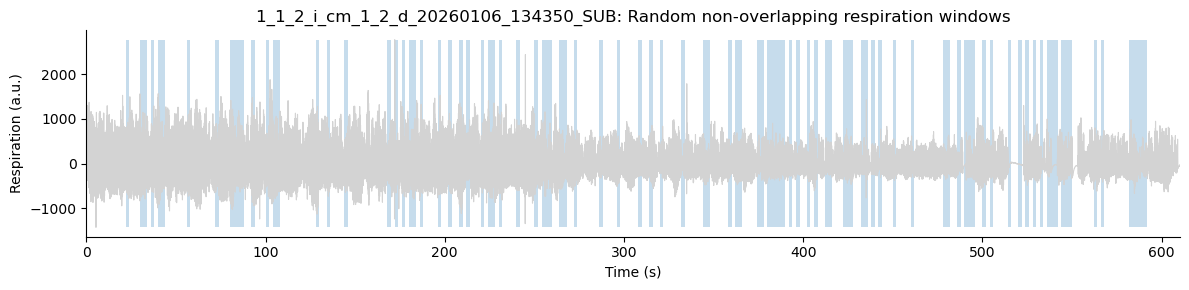

In [27]:
plot_sampled_windows(
    signal,
    time,
    windows,
    title=f"{fname}: Random non-overlapping respiration windows"
)

In [28]:
import os
import pandas as pd

rows = []

for f in analysis_files:
    
    fname = os.path.basename(f).replace(".h5", "")
    
    # -----------------------------
    # Load respiration
    # -----------------------------
    signal, time, fs, meta = load_clean_resp_signal(f)
    
    if signal is None or time is None:
        print("Bad file:", fname)
        continue
    
    # -----------------------------
    # Sample 2-sec windows
    # -----------------------------
    rates = sample_random_resp_windows(
        signal,
        time,
        fs,
        window_sec=2.0,
        n_samples=100,
        random_state=42
    )
    
    if len(rates) == 0:
        print("No windows:", fname)
        continue
    
    # -----------------------------
    # Parse subject + partner
    # -----------------------------
    parts = fname.split("_")
    
    # subject includes _2
    subject = f"{parts[0]}_{parts[1]}_{parts[2]}"
    
    # partner
    partner = f"{parts[4]}_{parts[5]}"
    
    # -----------------------------
    # Parse rank from END of filename
    # -----------------------------
    if fname.endswith("_SUB"):
        rank = "Subordinate"
    elif fname.endswith("_DOM"):
        rank = "Dominant"
    else:
        print("No rank label:", fname)
        continue
    
    # -----------------------------
    # Store ONE ROW PER WINDOW
    # -----------------------------
    for r in rates:
        rows.append({
            "Trial": fname,
            "Subject": subject,
            "Partner": partner,
            "Condition": "CM",
            "Rank": rank,
            "RespRate": r
        })

# -----------------------------
# Create dataframe
# -----------------------------
df_bla = pd.DataFrame(rows)

In [29]:
print(df_bla.shape)
print(df_bla.head())
print(df_bla["Rank"].value_counts())
print(df_bla["Subject"].nunique())

(2400, 6)
                                  Trial Subject Partner Condition         Rank   RespRate
0  1_1_2_i_cm_1_2_d_20260106_134350_SUB   1_1_2    cm_1        CM  Subordinate   7.432610
1  1_1_2_i_cm_1_2_d_20260106_134350_SUB   1_1_2    cm_1        CM  Subordinate   8.615406
2  1_1_2_i_cm_1_2_d_20260106_134350_SUB   1_1_2    cm_1        CM  Subordinate  10.675173
3  1_1_2_i_cm_1_2_d_20260106_134350_SUB   1_1_2    cm_1        CM  Subordinate   9.861152
4  1_1_2_i_cm_1_2_d_20260106_134350_SUB   1_1_2    cm_1        CM  Subordinate   8.633305
Rank
Dominant       1300
Subordinate    1100
Name: count, dtype: int64
17


In [33]:
df_bla

,Trial,Subject,Partner,Condition,Rank,RespRate
0,1_1_2_i_cm_1_2_d_20260106_134350_SUB,1_1_2,cm_1,CM,Subordinate,7.432610
1,1_1_2_i_cm_1_2_d_20260106_134350_SUB,1_1_2,cm_1,CM,Subordinate,8.615406
2,1_1_2_i_cm_1_2_d_20260106_134350_SUB,1_1_2,cm_1,CM,Subordinate,10.675173
3,1_1_2_i_cm_1_2_d_20260106_134350_SUB,1_1_2,cm_1,CM,Subordinate,9.861152
4,1_1_2_i_cm_1_2_d_20260106_134350_SUB,1_1_2,cm_1,CM,Subordinate,8.633305
...,...,...,...,...,...,...
2395,8_2_2_s_cm_8_1_d_20260106_113241_SUB,8_2_2,cm_8,CM,Subordinate,9.178109
2396,8_2_2_s_cm_8_1_d_20260106_113241_SUB,8_2_2,cm_8,CM,Subordinate,10.019311
2397,8_2_2_s_cm_8_1_d_20260106_113241_SUB,8_2_2,cm_8,CM,Subordinate,9.514590
2398,8_2_2_s_cm_8_1_d_20260106_113241_SUB,8_2_2,cm_8,CM,Subordinate,9.445059


In [34]:
df_bla = df_bla.drop(columns=["Partner"])

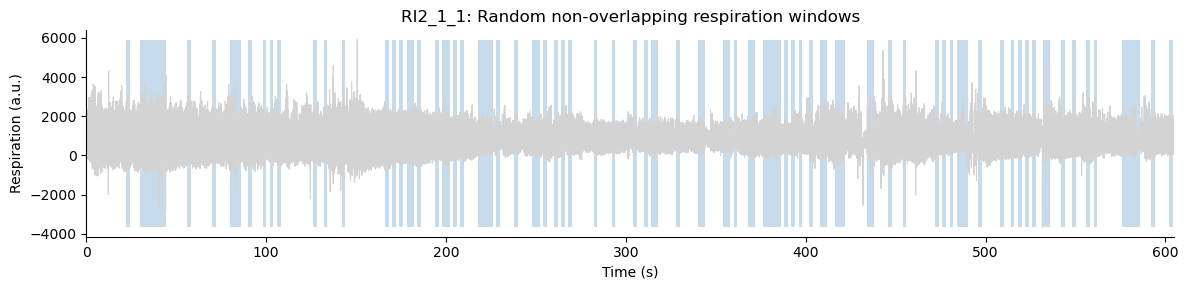

In [39]:
trial_key = "RI2_1_1"
resp_path = all_resp_paths[trial_key]

signal, time, fs, meta = load_clean_resp_signal(resp_path)

rates, windows = sample_random_resp_windows(
    signal,
    time,
    fs,
    window_sec=2.0,
    n_samples=100,      # use fewer for visualization
    random_state=42,
    return_windows=True
)

plot_sampled_windows(
    signal,
    time,
    windows,
    title=f"{trial_key}: Random non-overlapping respiration windows"
)


In [40]:
windows_sorted = sorted(windows, key=lambda x: x[0])


In [41]:
def plot_sampled_windows_zoom(signal, time, windows, t_start, t_end, title):
    fig, ax = plt.subplots(figsize=(10, 3))

    # Mask signal to zoom region
    mask = (time >= t_start) & (time <= t_end)
    ax.plot(time[mask], signal[mask], color="lightgray", lw=1)

    # Overlay windows
    for (w_start, w_stop) in windows:
        if w_stop < t_start or w_start > t_end:
            continue
        ax.axvspan(
            max(w_start, t_start),
            min(w_stop, t_end),
            color="tab:blue",
            alpha=0.35
        )

    ax.set_xlim(t_start, t_end)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Respiration (a.u.)")
    ax.set_title(title)

    sns.despine()
    plt.tight_layout()
    plt.show()


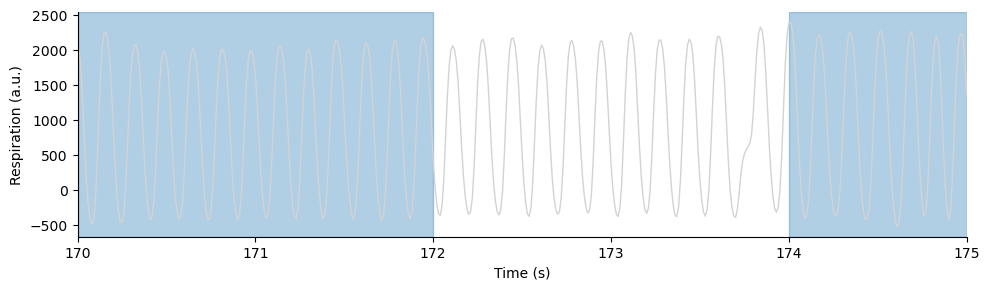

In [42]:
plot_sampled_windows_zoom(
    signal,
    time,
    windows_sorted,
    t_start=170,
    t_end=175,
    title=''
)


have to create this data for the rank_df and the df_rank to becreated downstream but my notebook used them upstream fyi 

In [43]:
rows = []

for trial, h5_path in all_resp_paths.items():
    signal, time, fs, meta = load_clean_resp_signal(h5_path)
    if signal is None:
        continue

    rates = sample_random_resp_windows(
        signal,
        time,
        fs,
        window_sec=2.0,
        n_samples=100,
        random_state=42
    )

    # metadata
    condition = trial.split("_")[0]
    subject = "_".join(trial.split("_")[1:3])
    rank = rank_map.get(subject, np.nan)

    for r in rates:
        rows.append({
            "Trial": trial,
            "Subject": subject,
            "Condition": condition,
            "Rank": rank,
            "RespRate": r
        })

resp_sample_df = pd.DataFrame(rows)
print(resp_sample_df.shape)
resp_sample_df.head()


(3900, 5)


,Trial,Subject,Condition,Rank,RespRate
0,RI1_3_6,3_6,RI1,Dominant,6.939260
1,RI1_3_6,3_6,RI1,Dominant,6.641048
2,RI1_3_6,3_6,RI1,Dominant,8.087553
3,RI1_3_6,3_6,RI1,Dominant,8.185180
4,RI1_3_6,3_6,RI1,Dominant,7.731036


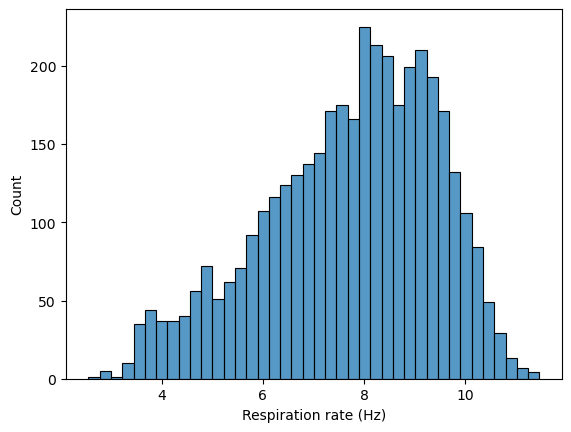

In [44]:
# how many samples per trial?
resp_sample_df.groupby("Trial").size().describe()

# rate distribution
sns.histplot(resp_sample_df["RespRate"], bins=40)
plt.xlabel("Respiration rate (Hz)")
plt.show()


In [45]:
df_val = resp_sample_df.query("Condition in ['RI1', 'RI2']").dropna()

X = df_val[["RespRate"]].to_numpy()
y = (df_val["Condition"] == "RI1").astype(int).to_numpy()
groups = df_val["Subject"].to_numpy()

cv = GroupKFold(n_splits=len(np.unique(groups)))
aucs = []

for tr, te in cv.split(X, y, groups):
    if len(np.unique(y[te])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear"
        ))
    ])

    model.fit(X[tr], y[tr])
    y_pred = model.predict_proba(X[te])[:, 1]
    aucs.append(roc_auc_score(y[te], y_pred))

print(f"Resp-only valence AUC: {np.mean(aucs):.2f}")


Resp-only valence AUC: 0.82


In [46]:
df_val = resp_sample_df.query("Condition in ['RI1', 'RI2']").dropna()

X = df_val[["RespRate"]].to_numpy()
y_valence = (df_val["Condition"] == "RI1").astype(int).to_numpy()
groups = df_val["Subject"].to_numpy()

cv = GroupKFold(n_splits=len(np.unique(groups)))

aucs_val = []
valence_coefs = []

for tr, te in cv.split(X, y_valence, groups):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear"
        ))
    ])

    # --- ALWAYS fit ---
    model.fit(X[tr], y_valence[tr])

    # --- ALWAYS store weights ---
    valence_coefs.append(
        model.named_steps["clf"].coef_.ravel()
    )

    # --- ONLY compute AUC if test fold has both classes ---
    if len(np.unique(y_valence[te])) >= 2:
        y_pred = model.predict_proba(X[te])[:, 1]
        aucs_val.append(roc_auc_score(y_valence[te], y_pred))

# convert to array AFTER loop
valence_coefs = np.asarray(valence_coefs)

print(f"Resp-only valence AUC: {np.mean(aucs_val):.2f}")
print(f"Stored weight folds: {valence_coefs.shape[0]}")


Resp-only valence AUC: 0.82
Stored weight folds: 8


In [47]:
print("=== FULL DATA CHECK ===")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique y values:", np.unique(y, return_counts=True))
print("Unique subjects:", np.unique(groups))
print("Number of subjects:", len(np.unique(groups)))
print()


=== FULL DATA CHECK ===
X shape: (1600, 1)
y shape: (1600,)
Unique y values: (array([0, 1]), array([800, 800], dtype=int64))
Unique subjects: ['1_1' '1_2' '2_3' '2_4' '3_5' '3_6' '4_7' '4_8']
Number of subjects: 8



Resp-only Valence AUC: 0.82 ± 0.03


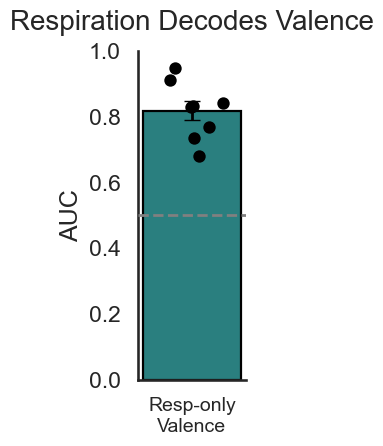

In [48]:
# --- Summary stats ---
auc_mean = np.mean(aucs)
auc_sem  = np.std(aucs) / np.sqrt(len(aucs))

print(f"Resp-only Valence AUC: {auc_mean:.2f} ± {auc_sem:.2f}")

# --- Plot ---
sns.set(style="white", context="talk")
plt.figure(figsize=(2.4, 4.8))

# Mean bar
plt.bar(
    [0],
    [auc_mean],
    width=0.25,
    color="#2A7F7F",   # same valence color you’ve been using
    edgecolor="black",
    linewidth=1.6,
    zorder=1
)

# Error bar (SEM)
plt.errorbar(
    0,
    auc_mean,
    yerr=auc_sem,
    fmt="none",
    ecolor="black",
    capsize=6,
    lw=2,
    zorder=3
)

# Per-fold dots (LOSO folds)
jitter = np.random.normal(0, 0.05, size=len(aucs))
plt.scatter(
    jitter,
    aucs,
    color="black",
    s=55,
    zorder=4
)

# Chance line
plt.axhline(0.5, ls="--", color="gray", lw=2, zorder=3)

# Axes
plt.xticks([0], ["Resp-only\nValence"], fontsize=14)
plt.ylabel("AUC", fontsize=18)
plt.ylim(0, 1)
plt.title("Respiration Decodes Valence", fontsize=20, pad=15)

sns.despine()
plt.tight_layout()
plt.show()


In [49]:
rank_df = resp_sample_df.query(
    "Condition in ['CM'] and Rank.notnull()"
).copy()

X = rank_df[["RespRate"]].to_numpy()
y = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()
subjects = rank_df["Subject"].to_numpy()


In [50]:
rank_df

,Trial,Subject,Condition,Rank,RespRate
2300,CM_1_1_d1_2,1_1,CM,Subordinate,7.127769
2301,CM_1_1_d1_2,1_1,CM,Subordinate,8.215050
2302,CM_1_1_d1_2,1_1,CM,Subordinate,7.136953
2303,CM_1_1_d1_2,1_1,CM,Subordinate,7.409129
2304,CM_1_1_d1_2,1_1,CM,Subordinate,7.059031
...,...,...,...,...,...
3095,CM_4_8_sub4_7,4_8,CM,Dominant,6.439114
3096,CM_4_8_sub4_7,4_8,CM,Dominant,10.622766
3097,CM_4_8_sub4_7,4_8,CM,Dominant,6.322787
3098,CM_4_8_sub4_7,4_8,CM,Dominant,8.560958


In [51]:
pair_groups = [
    ["1_1", "1_2"],
    ["2_3", "2_4"],
    ["3_5", "3_6"],
    ["4_7", "4_8"],
]


In [52]:
aucs = []
pair_labels = []

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    # skip invalid folds
    if len(np.unique(y[test_mask])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear"
        ))
    ])

    model.fit(X[train_mask], y[train_mask])
    y_pred = model.predict_proba(X[test_mask])[:, 1]

    auc = roc_auc_score(y[test_mask], y_pred)
    aucs.append(auc)
    pair_labels.append(f"{pair[0]} vs {pair[1]}")


In [53]:
auc_mean = np.mean(aucs)
auc_sem = np.std(aucs) / np.sqrt(len(aucs))

print(f"Rank decoding AUC: {auc_mean:.2f} ± {auc_sem:.2f}")


Rank decoding AUC: 0.63 ± 0.09


In [54]:
aucs = []
pair_labels = []
rank_coefs = []

df_rank = resp_sample_df.query(
    "Condition == 'CM' and Rank.notnull()"
).dropna()

X = df_rank[["RespRate"]].to_numpy()
y = (df_rank["Rank"] == "Dominant").astype(int).to_numpy()
subjects = df_rank["Subject"].to_numpy()

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    # skip invalid folds
    if len(np.unique(y[test_mask])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear"
        ))
    ])

    model.fit(X[train_mask], y[train_mask])

    # --- performance ---
    y_pred = model.predict_proba(X[test_mask])[:, 1]
    auc = roc_auc_score(y[test_mask], y_pred)
    aucs.append(auc)
    pair_labels.append(f"{pair[0]} vs {pair[1]}")

    # --- STORE WEIGHT ---
    rank_coefs.append(
        model.named_steps["clf"].coef_.ravel()
    )

rank_coefs = np.vstack(rank_coefs)

print(f"Rank AUC: {np.mean(aucs):.2f}")


Rank AUC: 0.63


In [55]:
df_rank

,Trial,Subject,Condition,Rank,RespRate
2300,CM_1_1_d1_2,1_1,CM,Subordinate,7.127769
2301,CM_1_1_d1_2,1_1,CM,Subordinate,8.215050
2302,CM_1_1_d1_2,1_1,CM,Subordinate,7.136953
2303,CM_1_1_d1_2,1_1,CM,Subordinate,7.409129
2304,CM_1_1_d1_2,1_1,CM,Subordinate,7.059031
...,...,...,...,...,...
3095,CM_4_8_sub4_7,4_8,CM,Dominant,6.439114
3096,CM_4_8_sub4_7,4_8,CM,Dominant,10.622766
3097,CM_4_8_sub4_7,4_8,CM,Dominant,6.322787
3098,CM_4_8_sub4_7,4_8,CM,Dominant,8.560958


create master data frame 

In [56]:
df_master_rank = pd.concat([rank_df, df_bla], ignore_index=True)

In [57]:
print(df_master_rank.shape)
print(df_master_rank["Rank"].value_counts())
print(df_master_rank["Subject"].nunique())

(3200, 5)
Rank
Dominant       1700
Subordinate    1500
Name: count, dtype: int64
25


new logisitc regression with all data for rank model 

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# -----------------------------
# Features + labels
# -----------------------------
X = df_master_rank[["RespRate"]].values

y = df_master_rank["Rank"].map({
    "Dominant": 1,
    "Subordinate": 0
}).values

groups = df_master_rank["Subject"].values

In [59]:
gkf = GroupKFold(n_splits=5)

aucs = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # -----------------------------
    # Model (same as yours)
    # -----------------------------
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear",
            class_weight="balanced"   # helps your slight imbalance
        ))
    ])
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)
    
    print(f"Fold {fold+1} AUC: {auc:.3f}")

Fold 1 AUC: 0.401
Fold 2 AUC: 0.373
Fold 3 AUC: 0.302
Fold 4 AUC: 0.630
Fold 5 AUC: 0.552


In [28]:
print("Valence AUC folds:", len(aucs))
print("Valence coef folds:", len(valence_coefs))


Valence AUC folds: 4
Valence coef folds: 8


In [29]:
valence_coefs = np.asarray(valence_coefs)
rank_coefs    = np.asarray(rank_coefs)


In [30]:
val_mean = valence_coefs.mean()
val_sem  = valence_coefs.std() / np.sqrt(len(valence_coefs))

rank_mean = rank_coefs.mean()
rank_sem  = rank_coefs.std() / np.sqrt(len(rank_coefs))


In [34]:
print("Valence labels:", np.unique(y_valence))
print("Rank labels:", np.unique(y_rank))


Valence labels: [0 1]
Rank labels: [0 1]


In [52]:
pair_results = []

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    if len(np.unique(y[test_mask])) < 2:
        print(f"Skipping {pair} (single class)")
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=0.1, solver="liblinear"))
    ])

    model.fit(X[train_mask], y[train_mask])
    y_pred = model.predict_proba(X[test_mask])[:, 1]

    auc = roc_auc_score(y[test_mask], y_pred)
    pair_results.append((pair, auc))

    print(f"Pair {pair}: AUC = {auc:.2f}")


Pair ['1_1', '1_2']: AUC = 0.49
Pair ['2_3', '2_4']: AUC = 0.55
Pair ['3_5', '3_6']: AUC = 0.67
Pair ['4_7', '4_8']: AUC = 0.54


In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

pair_df = rank_df.query("Subject in @bad_pair")

plt.figure(figsize=(4,4))
sns.boxplot(
    data=pair_df,
    x="Rank",
    y="RespRate",
    palette=["#999999", "#333333"]
)
sns.stripplot(
    data=pair_df,
    x="Rank",
    y="RespRate",
    color="black",
    size=4,
    jitter=True
)

plt.title(f"Respiration rate by rank\nPair {bad_pair[0]} vs {bad_pair[1]}")
plt.ylabel("Respiration rate (Hz)")
plt.tight_layout()
plt.show()


UndefinedVariableError: local variable 'bad_pair' is not defined

NameError: name 'bad_pair' is not defined

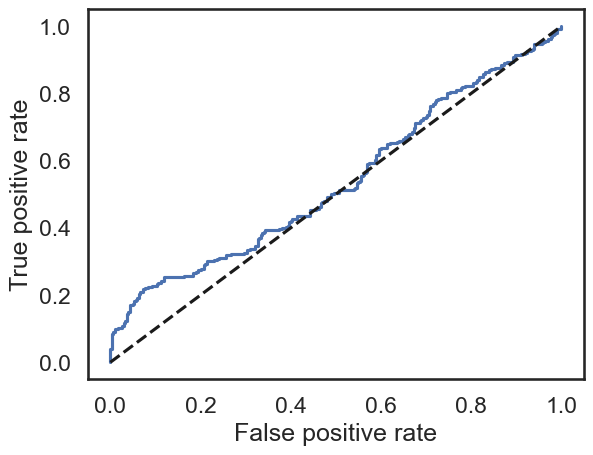

In [55]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y[test_mask], y_pred)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC — Pair {bad_pair}")
plt.show()


In [58]:
# ----------------------------------
# CM-only rank dataset
# ----------------------------------
rank_df = resp_sample_df.query(
    "Condition == 'CM' and Rank.notnull()"
).copy()

X = rank_df[["RespRate"]].to_numpy()
y = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()
#groups = rank_df["Subject"].to_numpy()   #  FIX IS HERE

print("Shapes:", X.shape, y.shape, groups.shape)

# ----------------------------------
# 5-fold GROUP cross-validation
# ----------------------------------
cv = GroupKFold(n_splits=5)
aucs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), 1):

    # Require both classes in test fold
    if len(np.unique(y[test_idx])) < 2:
        print(f" Skipping fold {fold} (single class in test)")
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict_proba(X[test_idx])[:, 1]

    auc = roc_auc_score(y[test_idx], y_pred)
    aucs.append(auc)

    print(f"Fold {fold}: AUC = {auc:.2f}")

print(f"\nRank decoding (CM only): {np.mean(aucs):.2f} ± {np.std(aucs)/np.sqrt(len(aucs)):.2f}")



Shapes: (800, 1) (800,) (1542,)


ValueError: Found input variables with inconsistent numbers of samples: [800, 800, 1542]

Fold 1: AUC = 0.64
Fold 2: AUC = 0.66
Fold 3: AUC = 0.64
Fold 4: AUC = 0.61
Fold 5: AUC = 0.59
Fold 6: AUC = 0.61
Fold 7: AUC = 0.68
Fold 8: AUC = 0.64

Rank decoding (CM only, forced window-level CV): 0.63 ± 0.01
Fold 8: Train n=700, Test n=100, Train classes=[0 1], Test classes=[0 1]


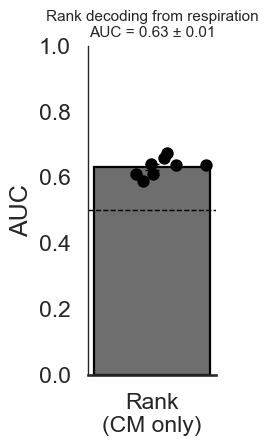

X shape: (800, 1)
y shape: (800,)
Features used: ['RespRate']
Label distribution: (array([0, 1]), array([400, 400], dtype=int64))


In [57]:
cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

aucs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict_proba(X[test_idx])[:, 1]

    auc = roc_auc_score(y[test_idx], y_pred)
    aucs.append(auc)

    print(f"Fold {fold}: AUC = {auc:.2f}")

print(
    f"\nRank decoding (CM only, forced window-level CV): "
    f"{np.mean(aucs):.2f} ± {np.std(aucs)/np.sqrt(len(aucs)):.2f}"
)

print(
    f"Fold {fold}: "
    f"Train n={len(train_idx)}, "
    f"Test n={len(test_idx)}, "
    f"Train classes={np.unique(y[train_idx])}, "
    f"Test classes={np.unique(y[test_idx])}"
)

# ----------------------------------
# Plot AUCs
# ----------------------------------
aucs = np.array(aucs)
auc_mean = aucs.mean()
auc_sem  = aucs.std(ddof=1) / np.sqrt(len(aucs))

# jitter for fold dots
jitter = np.random.normal(0, 0.04, size=len(aucs))

plt.figure(figsize=(2.6, 4.8))

# Mean bar
plt.bar(
    [0],
    [auc_mean],
    width=0.25,
    color="#6E6E6E",
    edgecolor="black",
    linewidth=1.6,
    zorder=1
)

# Error bar (SEM)
plt.errorbar(
    x=[0],
    y=[auc_mean],
    yerr=[auc_sem],
    fmt="none",
    ecolor="black",
    capsize=5,
    linewidth=1.6,
    zorder=3
)

# Per-fold dots
plt.scatter(
    jitter,
    aucs,
    color="black",
    s=55,
    zorder=4
)

# Chance line
plt.axhline(0.5, linestyle="--", color="black", linewidth=1)

# Formatting
plt.ylim(0, 1)
plt.xticks([0], ["Rank\n(CM only)"])
plt.ylabel("AUC")

plt.title(
    "Rank decoding from respiration\n"
    f"AUC = {auc_mean:.2f} ± {auc_sem:.2f}",
    fontsize=11
)
#remove top/right spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
plt.tight_layout()
plt.show()


print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features used:", rank_df[["RespRate"]].columns.tolist())
print("Label distribution:", np.unique(y, return_counts=True))



In [44]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

aucs = []
accs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    # Train
    model.fit(X[train_idx], y[train_idx])

    # Probabilities (for ROC AUC)
    y_prob = model.predict_proba(X[test_idx])[:, 1]

    # Hard predictions at 0.5 (for accuracy)
    y_hat = (y_prob >= 0.5).astype(int)

    # Metrics
    auc = roc_auc_score(y[test_idx], y_prob)
    acc = accuracy_score(y[test_idx], y_hat)

    aucs.append(auc)
    accs.append(acc)

    print(f"Fold {fold}: AUC = {auc:.2f}, Accuracy = {acc:.2f}")

print("\nSummary:")
print(f"ROC AUC: {np.mean(aucs):.2f} ± {np.std(aucs)/np.sqrt(len(aucs)):.2f}")
print(f"Accuracy: {np.mean(accs):.2f} ± {np.std(accs)/np.sqrt(len(accs)):.2f}")


Fold 1: AUC = 0.64, Accuracy = 0.63
Fold 2: AUC = 0.66, Accuracy = 0.63
Fold 3: AUC = 0.64, Accuracy = 0.61
Fold 4: AUC = 0.61, Accuracy = 0.57
Fold 5: AUC = 0.59, Accuracy = 0.60
Fold 6: AUC = 0.61, Accuracy = 0.59
Fold 7: AUC = 0.68, Accuracy = 0.63
Fold 8: AUC = 0.64, Accuracy = 0.60

Summary:
ROC AUC: 0.63 ± 0.01
Accuracy: 0.61 ± 0.01


In [ ]:
train_idx

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  12,  13,
        14,  15,  16,  18,  20,  21,  23,  24,  26,  27,  28,  29,  31,
        32,  33,  34,  35,  36,  37,  38,  39,  41,  42,  43,  44,  46,
        47,  48,  49,  50,  51,  52,  53,  55,  56,  57,  58,  59,  60,
        61,  62,  63,  64,  65,  66,  67,  69,  70,  71,  72,  73,  75,
        76,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 119,
       120, 121, 122, 123, 124, 125, 126, 128, 129, 131, 132, 133, 134,
       136, 137, 138, 139, 140, 141, 142, 143, 144, 146, 147, 148, 149,
       151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163,
       164, 165, 166, 167, 168, 169, 170, 174, 175, 176, 177, 179, 180,
       181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193,
       194, 195, 196, 197, 198, 200, 201, 202, 203, 204, 205, 20

In [ ]:
test_idx

array([ 11,  17,  19,  22,  25,  30,  40,  45,  54,  68,  74,  77,  96,
        97, 117, 118, 127, 130, 135, 145, 150, 171, 172, 173, 178, 199,
       211, 213, 249, 259, 260, 266, 292, 330, 331, 365, 367, 370, 373,
       384, 388, 392, 416, 418, 420, 427, 437, 438, 440, 446, 455, 501,
       512, 513, 520, 522, 534, 543, 555, 573, 585, 590, 602, 613, 622,
       624, 625, 655, 658, 665, 687, 692, 718, 722, 738, 744, 764, 782,
       790, 791])

5 sec long random signal 

In [ ]:
rows = []

for trial, h5_path in all_resp_paths.items():
    signal, time, fs, meta = load_clean_resp_signal(h5_path)
    if signal is None:
        continue

    # --- determine how many 5-s windows are possible ---
    window_sec = 2.0
    window_len = int(window_sec * fs)
    total_len = len(signal)

    max_windows = total_len // window_len
    if max_windows < 1:
        print(f"Skipping {trial}: <1 usable 5s window")
        continue

    n_samples_use = min(100, max_windows)

    # --- sample respiration windows ---
    rates = sample_random_resp_windows(
        signal,
        time,
        fs,
        window_sec=window_sec,
        n_samples=n_samples_use,
        random_state=42
    )

    # --- metadata ---
    condition = trial.split("_")[0]
    subject = "_".join(trial.split("_")[1:3])
    rank = rank_map.get(subject, np.nan)

    for r in rates:
        rows.append({
            "Trial": trial,
            "Subject": subject,
            "Condition": condition,
            "Rank": rank,
            "RespRate": r,
            "WindowSec": 2.0
        })

resp_sample_df_5sec = pd.DataFrame(rows)
print(resp_sample_df_5sec.shape)
resp_sample_df_5sec.head()


(3842, 6)


,Trial,Subject,Condition,Rank,RespRate,WindowSec
0,RI1_3_6,3_6,RI1,Dominant,7.215719,5.0
1,RI1_3_6,3_6,RI1,Dominant,8.312670,5.0
2,RI1_3_6,3_6,RI1,Dominant,7.281338,5.0
3,RI1_3_6,3_6,RI1,Dominant,9.803683,5.0
4,RI1_3_6,3_6,RI1,Dominant,7.025499,5.0


In [ ]:
windows_sorted = sorted(windows, key=lambda x: x[0])


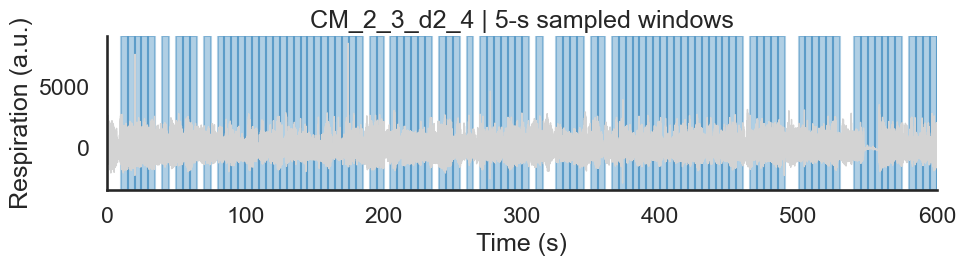

In [ ]:
plot_sampled_windows_zoom(
    signal,
    time,
    windows_sorted,
    t_start=0,
    t_end=600,
    title=f"{trial} | 5-s sampled windows"
)


In [46]:
df_val = resp_sample_df_5sec.query("Condition in ['RI1', 'RI2']").dropna()

X = df_val[["RespRate"]].to_numpy()
y = (df_val["Condition"] == "RI1").astype(int).to_numpy()
groups = df_val["Subject"].to_numpy()

cv = GroupKFold(n_splits=len(np.unique(groups)))
aucs = []

for tr, te in cv.split(X, y, groups):
    if len(np.unique(y[te])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear"
        ))
    ])

    model.fit(X[tr], y[tr])
    y_pred = model.predict_proba(X[te])[:, 1]
    aucs.append(roc_auc_score(y[te], y_pred))

print(f"Resp-only valence AUC: {np.mean(aucs):.2f}")

Resp-only valence AUC: 0.85


In [47]:
rank_df_5s = resp_sample_df_5sec.query(
    "Condition in ['CM','RI1','RI2'] and Rank.notnull()"
).copy()


In [48]:
X = rank_df_5s[["RespRate"]].to_numpy()
y = (rank_df_5s["Rank"] == "Dominant").astype(int).to_numpy()
subjects = rank_df_5s["Subject"].to_numpy()


In [49]:
aucs_5s = []
pair_labels_5s = []

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    if len(np.unique(y[test_mask])) < 2:
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X[train_mask], y[train_mask])
    y_pred = model.predict_proba(X[test_mask])[:, 1]

    auc = roc_auc_score(y[test_mask], y_pred)
    aucs_5s.append(auc)
    pair_labels_5s.append(f"{pair[0]} vs {pair[1]}")


In [50]:
mean_auc_5s = np.mean(aucs_5s)
sem_auc_5s  = np.std(aucs_5s) / np.sqrt(len(aucs_5s))

print(f"Rank decoding (5-s bouts): {mean_auc_5s:.3f} ± {sem_auc_5s:.3f}")


Rank decoding (5-s bouts): 0.563 ± 0.032
